In [17]:
class node():
    def __init__(self, xpos, ypos):

        self.xpos = xpos
        self.ypos = ypos

    def __repr__(self):
        return f"node(xpos={self.xpos}, ypos={self.ypos})"

   

In [18]:
import random
class mapper():
    def __init__(self):

        repete = int(input("Number of population nodes: "))
        grid = int(input("Grid size"))

        self.node_dic = {}

        i = 0
        while i < repete: 

            

            xx = random.uniform(0, grid)
            yy = random.uniform(0, grid)


            new = node(xx,yy)

            self.node_dic.update({new: {'connections': [], 'attributes': []}})

            i += 1


            
        

In [22]:
import networkx as nx


class connector():
    def __init__(self, node_dic):

        self.nodes = node_dic

        av = float(input("Connection radius (av): "))

       #Create connections based on distance

        for node1 in self.nodes:
            for node2 in self.nodes:

                if node1 != node2:

                    dist = (
                        ((node1.xpos - node2.xpos) ** 2) +
                        ((node1.ypos - node2.ypos) ** 2)
                    ) ** 0.5

                    if dist <= av:
                        self.nodes[node1]['connections'].append(node2)

      #Ensure no isolated nodes

        for node1 in self.nodes:

            if len(self.nodes[node1]['connections']) == 0:

                closest_node = None
                closest_dist = float('inf')

                for node2 in self.nodes:

                    if node1 != node2:

                        dist = (
                            ((node1.xpos - node2.xpos) ** 2) +
                            ((node1.ypos - node2.ypos) ** 2)
                        ) ** 0.5

                        if dist < closest_dist:
                            closest_dist = dist
                            closest_node = node2

                self.nodes[node1]['connections'].append(closest_node)

        #Build network

        G = nx.Graph()

        for node in self.nodes:
            G.add_node(node)

        for node in self.nodes:
            for neighbor in self.nodes[node]['connections']:
                G.add_edge(node, neighbor)

       #Force graph to not be connected

        while not nx.is_connected(G):

            components = list(nx.connected_components(G))

            comp1 = list(components[0])
            comp2 = list(components[1])

            closest_pair = None
            closest_dist = float('inf')

            # Find closest nodes between components
            for node1 in comp1:
                for node2 in comp2:

                    dist = (
                        ((node1.xpos - node2.xpos) ** 2) +
                        ((node1.ypos - node2.ypos) ** 2)
                    ) ** 0.5

                    if dist < closest_dist:
                        closest_dist = dist
                        closest_pair = (node1, node2)

            # Add bridge edge
            node1, node2 = closest_pair

            self.nodes[node1]['connections'].append(node2)
            self.nodes[node2]['connections'].append(node1)

            G.add_edge(node1, node2)

        self.graph = G
        

Number of population nodes:  100
Grid size 20
Connection radius (av):  1


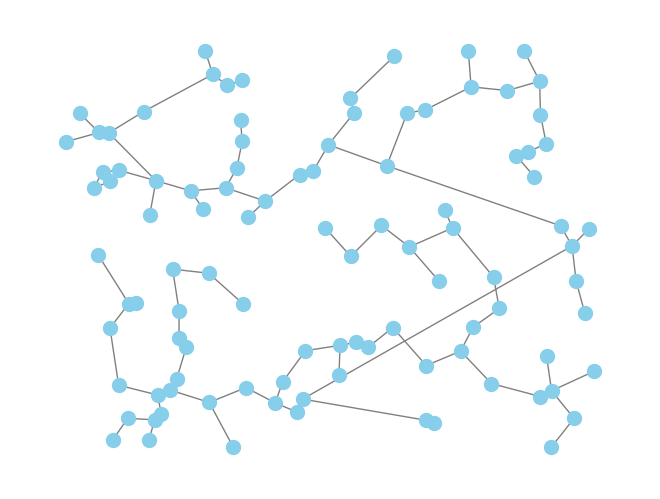

In [24]:
import networkx as nx
import matplotlib.pyplot as plt

my_mapper = mapper()
my_connector = connector(my_mapper.node_dic)
#print(my_mapper.node_dic)

g = nx.Graph()
pos = {}

for start in my_mapper.node_dic:
    g.add_node(start)
    pos.update({start: (start.xpos, start.ypos)})
    for connect in my_mapper.node_dic[start]['connections']:
        g.add_edge(start, connect)

nx.draw(g, pos, with_labels=False, node_color='skyblue', node_size=100, edge_color='gray')
plt.show()
